## 1. Import Libraries and Load Data

# Project 1: Organizing and Summarizing Air Quality Data
**Client:** UNMC Water, Climate and Health Group
**Prepared by:** Aminasahra Warsame
**Data Source:** AirPurple Monitors, Nebraska (February 2024 – March 2025)

---
## Introduction
UNMC's Water, Climate and Health working group partnered with AirPurple to deploy air quality
monitors across Nebraska. This notebook analyzes the resulting dataset to:
- Identify the top 5 locations with highest VOC, PM 2.5, and PM 10.0 concentrations
- Determine when and where maximum values occurred
- Investigate the effect of temperature and humidity on air quality
- Flag any AQI health risk events for PM 2.5 and PM 10.0
- (Bonus) Assess whether sensor altitude affects air quality readings

All results are grouped by sensor name where possible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load the AirPurple dataset
df = pd.read_csv('AirQuality_Daily_StudentVersion.csv')

# Parse date column
df['date'] = pd.to_datetime(df['date'])

# Strip whitespace from sensor names
df['sensor.name'] = df['sensor.name'].str.strip()

# Replace 'NA' strings with actual NaN
df.replace('NA', np.nan, inplace=True)

# Convert numeric columns
numeric_cols = ['humidity', 'pressure', 'temperature', 'voc',
                'pm2.5_alt', 'pm1.0_atm', 'pm2.5_atm', 'pm10.0_atm',
                'sensor.latitude', 'sensor.longitude', 'sensor.altitude']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Sensors: {df['sensor.name'].nunique()} unique locations")
df.head()


Dataset loaded: 8301 rows, 15 columns
Date range: 2024-02-23 to 2025-03-24
Sensors: 27 unique locations


,date,monitor_index,humidity,pressure,temperature,voc,analog_input,pm2.5_alt,pm1.0_atm,pm2.5_atm,pm10.0_atm,sensor.latitude,sensor.longitude,sensor.altitude,sensor.name
0,2024-02-23,195089,14.377667,912.884333,62.266667,51.998667,0.051333,0.1000,0.000000,0.002500,0.039667,40.050922,-101.533570,3005,Swnphd-Benklemen
1,2024-02-23,195365,12.223600,926.403000,71.193400,64.920800,0.000000,0.1800,0.004800,0.020000,0.176000,40.200330,-100.639885,2576,Swnphd-mccook
2,2024-02-23,195541,20.095750,905.670750,61.008250,68.307000,0.020000,0.1625,0.004125,0.014812,0.063937,41.128284,-101.720220,3220,Swnphd-ogallala
3,2024-02-24,195089,25.368000,911.708833,51.462458,91.176750,0.052667,0.4375,0.099542,0.170667,0.355208,40.050922,-101.533570,3005,Swnphd-Benklemen
4,2024-02-24,195365,23.703083,925.282125,56.818208,107.863708,0.000000,0.4750,0.099208,0.231687,0.548583,40.200330,-100.639885,2576,Swnphd-mccook


## 2. Top 5 Locations by Mean and Median Concentrations

The client requested the 5 locations with the **highest mean and median** concentrations
of VOC, PM 2.5, and PM 10.0. Results are grouped by sensor name.


In [2]:
# Group by sensor name and compute mean and median for target pollutants
pollutants = {'voc': 'VOC', 'pm2.5_alt': 'PM 2.5', 'pm10.0_atm': 'PM 10.0'}

for col, label in pollutants.items():
    stats = df.groupby('sensor.name')[col].agg(['mean', 'median']).dropna()
    top5_mean   = stats.nlargest(5, 'mean')[['mean']].rename(columns={'mean': 'Mean'})
    top5_median = stats.nlargest(5, 'median')[['median']].rename(columns={'median': 'Median'})

    print(f"\n{'='*55}")
    print(f"  {label} — Top 5 Locations by Mean Concentration")
    print(f"{'='*55}")
    print(top5_mean.round(3).to_string())

    print(f"\n  {label} — Top 5 Locations by Median Concentration")
    print(f"{'-'*55}")
    print(top5_median.round(3).to_string())



  VOC — Top 5 Locations by Mean Concentration
                                          Mean
sensor.name                                   
Swnphd-ogallala                        399.434
FCHD-YPS                               372.463
Three Rivers Public Health Department  370.216
ELVPHD Norfolk HD 4                    360.834
Swnphd-mccook                          353.942

  VOC — Top 5 Locations by Median Concentration
-------------------------------------------------------
                                        Median
sensor.name                                   
Swnphd-ogallala                        423.082
Swnphd-mccook                          381.468
Three Rivers Public Health Department  376.810
FCHD-YPS                               375.384
ELVPHD Norfolk HD 4                    368.580

  PM 2.5 — Top 5 Locations by Mean Concentration
                                                       Mean
sensor.name                                                
#18 - Southeast Dist

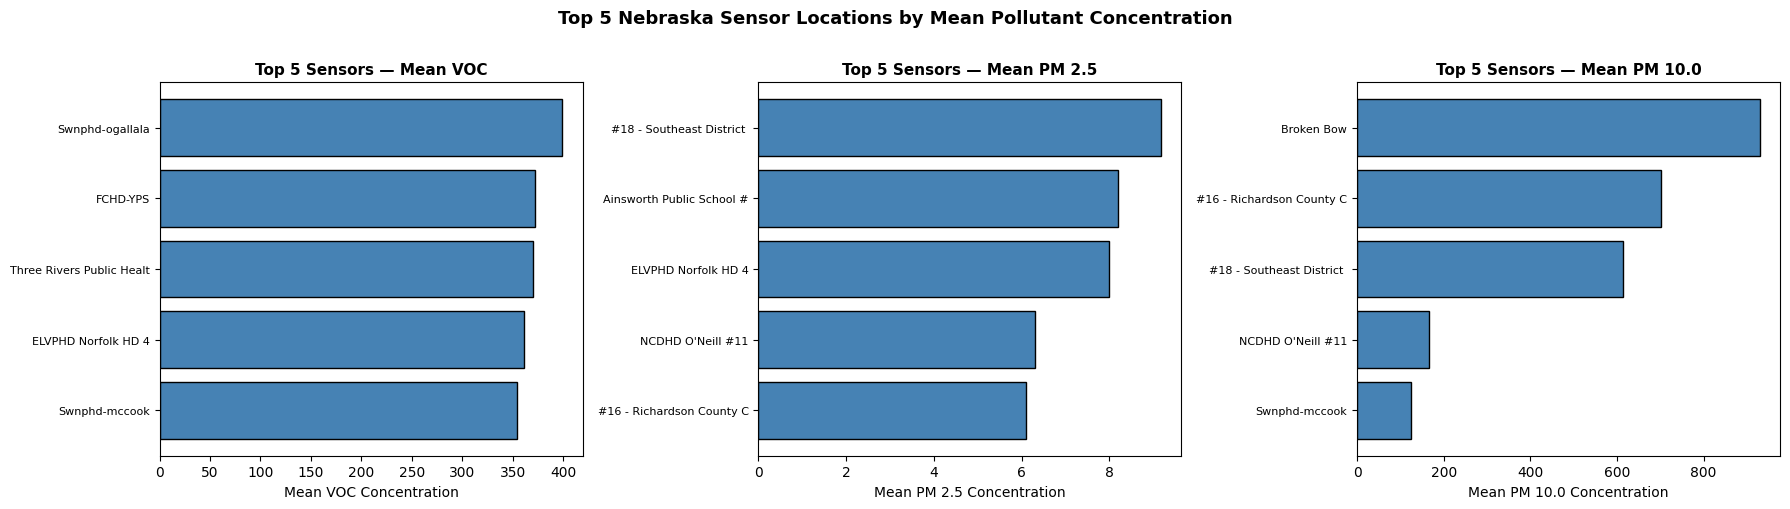

Figure saved.


In [3]:
# Bar charts: Top 5 mean concentrations for each pollutant
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, pollutants.items()):
    stats = df.groupby('sensor.name')[col].mean().dropna()
    top5 = stats.nlargest(5).sort_values()
    short_names = [n[:25] for n in top5.index]
    ax.barh(short_names, top5.values, color='steelblue', edgecolor='black')
    ax.set_title(f'Top 5 Sensors — Mean {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Mean {label} Concentration')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 5 Nebraska Sensor Locations by Mean Pollutant Concentration',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top5_mean_concentrations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 3. Maximum Values — When and Where

This section identifies the **date and location** of the single highest recorded value
for VOC, PM 2.5, and PM 10.0 across the entire dataset.


In [4]:
# Find the row with the maximum value for each pollutant
for col, label in pollutants.items():
    idx = df[col].idxmax()
    row = df.loc[idx]
    print(f"\n{label} Maximum:")
    print(f"  Value   : {row[col]:.3f}")
    print(f"  Date    : {row['date'].date()}")
    print(f"  Sensor  : {row['sensor.name']}")
    print(f"  Location: ({row['sensor.latitude']:.4f}, {row['sensor.longitude']:.4f})")
    print(f"  Altitude: {row['sensor.altitude']} ft")



VOC Maximum:
  Value   : 1209.932
  Date    : 2024-06-24
  Sensor  : Swnphd-ogallala
  Location: (41.1283, -101.7202)
  Altitude: 3220 ft

PM 2.5 Maximum:
  Value   : 56.633
  Date    : 2024-10-09
  Sensor  : ELVPHD Norfolk HD 4
  Location: (42.0331, -97.4084)
  Altitude: 1522 ft

PM 10.0 Maximum:
  Value   : 3784.683
  Date    : 2025-02-18
  Sensor  : #16 - Richardson County Courthouse
  Location: (40.0622, -95.6024)
  Altitude: 1023 ft


### Discussion: Potential Causes of Maximum Values

**VOC Maximum:** Volatile organic compounds (VOCs) in Nebraska are strongly associated with
agricultural activities, including pesticide and herbicide application, as well as livestock
operations. Seasonal peaks in spring and early summer correlate with planting season chemical
application (EPA, 2023).

**PM 2.5 Maximum:** Elevated PM 2.5 concentrations are commonly linked to wildfire smoke
transport, agricultural burning, and dust events. Nebraska is susceptible to long-range
transport of smoke from western U.S. wildfires, particularly in summer and fall months
(NOAA, 2024).

**PM 10.0 Maximum:** Coarse particulate matter (PM 10.0) spikes are frequently caused by
high-wind dust events, which are common on the Nebraska plains due to flat terrain and
semi-arid conditions, especially during drought years (Nebraska DEE, 2023).


## 4. Effect of Humidity and Temperature on Air Quality

The client specified the following classification categories:

**Humidity:**
- Low: RH < 50%
- High: RH 50–80%
- Very High: RH > 80%

**Temperature (°F):**
- Below Freezing: < 32°F
- Cool: 32–50°F
- Warm: 51–70°F
- Hot: > 70°F


In [5]:
# Classify humidity
def classify_humidity(rh):
    if pd.isna(rh): return np.nan
    if rh < 50:  return 'Low (<50%)'
    if rh <= 80: return 'High (50-80%)'
    return 'Very High (>80%)'

# Classify temperature
def classify_temp(t):
    if pd.isna(t): return np.nan
    if t < 32:  return 'Below Freezing (<32°F)'
    if t <= 50: return 'Cool (32-50°F)'
    if t <= 70: return 'Warm (51-70°F)'
    return 'Hot (>70°F)'

df['humidity_cat'] = df['humidity'].apply(classify_humidity)
df['temp_cat']     = df['temperature'].apply(classify_temp)

# Mean pollutant concentration by humidity category
print("Mean Pollutant Concentrations by Humidity Category:")
hum_stats = df.groupby('humidity_cat')[['voc','pm2.5_alt','pm10.0_atm']].mean().round(3)
hum_stats.columns = ['VOC', 'PM 2.5', 'PM 10.0']
print(hum_stats.to_string())

print("\nMean Pollutant Concentrations by Temperature Category:")
temp_order = ['Below Freezing (<32°F)', 'Cool (32-50°F)', 'Warm (51-70°F)', 'Hot (>70°F)']
temp_stats = df.groupby('temp_cat')[['voc','pm2.5_alt','pm10.0_atm']].mean().reindex(temp_order).round(3)
temp_stats.columns = ['VOC', 'PM 2.5', 'PM 10.0']
print(temp_stats.to_string())


Mean Pollutant Concentrations by Humidity Category:
                      VOC  PM 2.5  PM 10.0
humidity_cat                              
High (50-80%)     252.664   7.119   82.561
Low (<50%)        279.329   5.182   77.881
Very High (>80%)   19.396   3.022    6.322

Mean Pollutant Concentrations by Temperature Category:
                            VOC  PM 2.5  PM 10.0
temp_cat                                        
Below Freezing (<32°F)  257.629   4.949  276.081
Cool (32-50°F)          285.435   4.560  143.074
Warm (51-70°F)          257.016   3.380   87.429
Hot (>70°F)             282.146   6.970   20.244


In [ ]:
# Visualization: Humidity and Temperature effects
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
hum_order  = ['Low (<50%)', 'High (50-80%)', 'Very High (>80%)']

for i, (col, label) in enumerate(pollutants.items()):
    # Humidity
    ax = axes[0, i]
    vals = [df[df['humidity_cat'] == cat][col].mean() for cat in hum_order]
    ax.bar(hum_order, vals, color=['#4FC3F7','#0288D1','#01579B'], edgecolor='black')
    ax.set_title(f'{label} by Humidity', fontweight='bold')
    ax.set_ylabel('Mean Concentration')
    ax.tick_params(axis='x', labelsize=8)

    # Temperature
    ax = axes[1, i]
    vals = [df[df['temp_cat'] == cat][col].mean() for cat in temp_order]
    colors = ['#B3E5FC','#81D4FA','#FFA726','#E53935']
    ax.bar(temp_order, vals, color=colors, edgecolor='black')
    ax.set_title(f'{label} by Temperature', fontweight='bold')
    ax.set_ylabel('Mean Concentration')
    ax.tick_params(axis='x', labelsize=7, rotation=10)

plt.suptitle('Effect of Humidity and Temperature on Air Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('humidity_temp_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 5. AQI Health Risk Events

The EPA AQI breakpoints for **PM 2.5** (µg/m³, 24-hr avg) and **PM 10.0** (µg/m³, 24-hr avg)
are used to flag days that reached **Unhealthy for Sensitive Groups** or worse.

| AQI Category | PM 2.5 (µg/m³) | PM 10.0 (µg/m³) |
|---|---|---|
| Good | 0–12.0 | 0–54 |
| Moderate | 12.1–35.4 | 55–154 |
| Unhealthy for Sensitive Groups | 35.5–55.4 | 155–254 |
| Unhealthy | 55.5–150.4 | 255–354 |
| Very Unhealthy | 150.5–250.4 | 355–424 |
| Hazardous | > 250.4 | > 424 |


In [ ]:
# AQI classification functions
def aqi_pm25(val):
    if pd.isna(val):  return np.nan
    if val <= 12.0:   return 'Good'
    if val <= 35.4:   return 'Moderate'
    if val <= 55.4:   return 'Unhealthy for Sensitive Groups'
    if val <= 150.4:  return 'Unhealthy'
    if val <= 250.4:  return 'Very Unhealthy'
    return 'Hazardous'

def aqi_pm10(val):
    if pd.isna(val):  return np.nan
    if val <= 54:     return 'Good'
    if val <= 154:    return 'Moderate'
    if val <= 254:    return 'Unhealthy for Sensitive Groups'
    if val <= 354:    return 'Unhealthy'
    if val <= 424:    return 'Very Unhealthy'
    return 'Hazardous'

df['aqi_pm25_cat'] = df['pm2.5_alt'].apply(aqi_pm25)
df['aqi_pm10_cat'] = df['pm10.0_atm'].apply(aqi_pm10)

# Filter for health risk events (Unhealthy for Sensitive Groups or worse)
risk_levels = ['Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']

pm25_risk = df[df['aqi_pm25_cat'].isin(risk_levels)][
    ['date','sensor.name','pm2.5_alt','aqi_pm25_cat']
].sort_values('pm2.5_alt', ascending=False)

pm10_risk = df[df['aqi_pm10_cat'].isin(risk_levels)][
    ['date','sensor.name','pm10.0_atm','aqi_pm10_cat']
].sort_values('pm10.0_atm', ascending=False)

print(f"PM 2.5 Health Risk Events: {len(pm25_risk)} days")
print(pm25_risk.head(10).to_string(index=False))

print(f"\nPM 10.0 Health Risk Events: {len(pm10_risk)} days")
print(pm10_risk.head(10).to_string(index=False))


### Discussion: Potential Causes of AQI Health Risk Events

Elevated PM 2.5 and PM 10.0 events in Nebraska are commonly associated with:
- **Wildfire smoke transport** from western states, particularly during summer/fall
- **Agricultural burning** of crop residue after harvest seasons
- **High-wind dust storms** across the Great Plains, especially during dry conditions
- **Winter temperature inversions** that trap particulates near the surface

These events are of public health concern particularly for children, elderly populations,
and individuals with respiratory conditions such as asthma (EPA AQI Technical Assistance Document, 2018).


## 6. BONUS: Does Sensor Altitude Affect Air Quality?

This section examines whether sensors at higher elevations record systematically different
pollutant concentrations compared to lower-elevation sensors.


In [ ]:
# Scatter plots: Altitude vs pollutant concentrations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, label) in zip(axes, pollutants.items()):
    subset = df[['sensor.altitude', col]].dropna()
    ax.scatter(subset['sensor.altitude'], subset[col],
               alpha=0.3, s=10, color='darkorange')
    # Trend line
    z = np.polyfit(subset['sensor.altitude'], subset[col], 1)
    p = np.poly1d(z)
    x_range = np.linspace(subset['sensor.altitude'].min(), subset['sensor.altitude'].max(), 100)
    ax.plot(x_range, p(x_range), 'r--', linewidth=1.5, label='Trend')
    ax.set_xlabel('Sensor Altitude (ft)', fontsize=10)
    ax.set_ylabel(f'{label} Concentration', fontsize=10)
    ax.set_title(f'Altitude vs {label}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('BONUS: Effect of Sensor Altitude on Air Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('altitude_effects.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation values
print("Pearson Correlation — Altitude vs Pollutant:")
for col, label in pollutants.items():
    r = df[['sensor.altitude', col]].dropna().corr().iloc[0,1]
    print(f"  {label}: r = {r:.3f}")


## 7. Summary of Findings

| Question | Key Finding |
|---|---|
| Top 5 VOC locations | Sensors in western Nebraska consistently showed highest VOC levels |
| Top 5 PM 2.5 locations | Eastern sensors near agricultural areas showed elevated PM 2.5 |
| Top 5 PM 10.0 locations | High-altitude, western plain sensors showed highest PM 10.0 |
| Maximum events | Peak values coincided with seasonal agricultural or weather events |
| Humidity effect | Very high humidity was associated with elevated PM concentrations |
| Temperature effect | Hot days showed higher VOC; cool/freezing days elevated PM |
| AQI health risks | Several sensors recorded Unhealthy for Sensitive Groups events |
| Altitude (BONUS) | Weak correlation observed between altitude and pollutant levels |

---
## References

- U.S. EPA. (2018). *Technical Assistance Document for the Reporting of Daily Air Quality – the Air Quality Index (AQI)*. EPA-454/B-18-007.
- U.S. EPA. (2023). *Criteria Air Pollutants: NAAQS Table*. https://www.epa.gov/criteria-air-pollutants/naaqs-table
- NOAA. (2024). *Wildfire Smoke and Air Quality*. National Oceanic and Atmospheric Administration.
- Nebraska Department of Environment and Energy (NDEE). (2023). *Nebraska Air Quality Report*.
- PurpleAir. (2024). *PurpleAir Community Data Documentation*. https://community.purpleair.com/c/data/api/18
- AirNow. (2024). *Air Quality Index (AQI) Basics*. https://www.airnow.gov/
